# Chip Dynamics — ML Prediction

Run the trained **amoeba / plasmodium / slug** U-Net and the **pillar** U-Net on a
single CZI frame (chosen timepoint + channel) and display the results side-by-side.

In [1]:
# ── Standard + chipanalysis imports ──────────────────────────────────────────
from chipanalysis.utils.file_reader import get_frame, get_pixel_sizes_um, get_timestamps_by_T
from chipanalysis.utils.maye_video_axio import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from skimage import exposure

import torch
import torch.nn as nn
import torch.nn.functional as F

%load_ext autoreload
%autoreload 2
%matplotlib widget

## Parameters — edit these before running

In [2]:
# ── CZI file ─────────────────────────────────────────────────────────────────
CZI_PATH   = "/Volumes/vangestel/Coco/ZeissData/TestSizesDetect.czi"   # ← change this

# ── Frame selection ───────────────────────────────────────────────────────────
TIMEPOINT  = 0    # T index (0-based)
CHANNEL    = 2    # channel for the cell / organism detector
CHANNEL_BF = 2    # brightfield channel used by the pillar detector

# ── Display stretch ───────────────────────────────────────────────────────────
STRETCH_MIN = 1
STRETCH_MAX = 99.5
GAMMA       = 0.45

# ── Saved model paths ─────────────────────────────────────────────────────────
# Point these to the .pth files produced by the training notebooks.
CELL_MODEL_PATH   = "/Users/bisot/Documents/PostDoc2/training_data_cells/unet_cell_best.pth"
PILLAR_MODEL_PATH = "/Users/bisot/Documents/PostDoc2/training_data_pillars/unet_pillar_best.pth"

# ── Inference parameters ──────────────────────────────────────────────────────
PATCH_SIZE_PX   = 256
PATCH_STRIDE_PX = 128
THRESHOLD_CELL   = 0.8   # probability cut-off for cell mask
THRESHOLD_PILLAR = 0.5   # probability cut-off for pillar mask

## Load CZI file and extract frame

.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value
File        : TestSizesDetect.czi
Dimensions  : {'S': 1, 'T': 60, 'C': 3, 'Y': 857, 'X': 630}
Pixel size  : 1.2232 µm/px

Cell channel   : 2  →  shape (857, 630)
BF channel     : 2  →  shape (857, 630)
Timepoint      : 0


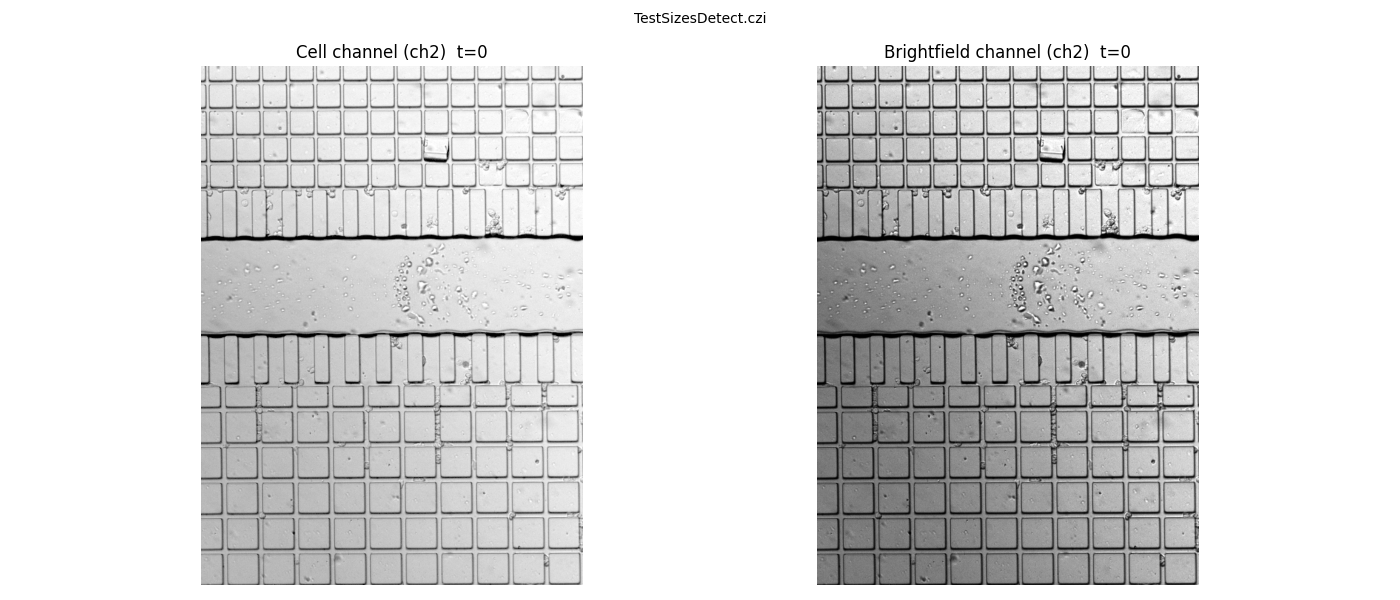

In [3]:
czi_path   = Path(CZI_PATH)
czi        = CziFile(czi_path)

dims       = czi.dims
sizes      = czi.size
dim_sizes  = dict(zip(dims, sizes))
pixel_size = get_pixel_sizes_um(czi)
px_um      = pixel_size["X"]

print(f"File        : {czi_path.name}")
print(f"Dimensions  : {dim_sizes}")
print(f"Pixel size  : {px_um:.4f} µm/px")

# ── Extract the requested frame (cell / organism channel) ─────────────────────
img_cell, img_cell_disp = get_frame(
    czi, TIMEPOINT, CHANNEL,
    gamma=GAMMA, stretch_min=STRETCH_MIN, stretch_max=STRETCH_MAX,
)

# ── Extract the brightfield frame for the pillar model ────────────────────────
img_bf, img_bf_disp = get_frame(
    czi, TIMEPOINT, CHANNEL_BF,
    gamma=1.0, stretch_min=1, stretch_max=99.5,
)

print(f"\nCell channel   : {CHANNEL}  →  shape {img_cell.shape}")
print(f"BF channel     : {CHANNEL_BF}  →  shape {img_bf.shape}")
print(f"Timepoint      : {TIMEPOINT}")

# ── Quick preview ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(img_cell_disp, cmap="gray")
ax1.set_title(f"Cell channel (ch{CHANNEL})  t={TIMEPOINT}")
ax1.axis("off")
ax2.imshow(img_bf_disp, cmap="gray")
ax2.set_title(f"Brightfield channel (ch{CHANNEL_BF})  t={TIMEPOINT}")
ax2.axis("off")
plt.suptitle(czi_path.name, fontsize=10)
plt.tight_layout()
plt.show()

## U-Net architecture (shared by both models)

In [4]:
# ── U-Net definition (identical architecture used in both training notebooks) ──

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=(32, 64, 128, 256)):
        super().__init__()
        self.pool      = nn.MaxPool2d(2, 2)
        self.downs     = nn.ModuleList()
        self.ups_trans = nn.ModuleList()
        self.ups_conv  = nn.ModuleList()

        ch = in_channels
        for feat in features:
            self.downs.append(DoubleConv(ch, feat))
            ch = feat

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for feat in reversed(features):
            self.ups_trans.append(nn.ConvTranspose2d(feat * 2, feat, 2, stride=2))
            self.ups_conv.append(DoubleConv(feat * 2, feat))

        self.final = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        for i, (up_t, up_c) in enumerate(zip(self.ups_trans, self.ups_conv)):
            x = up_t(x)
            s = skips[-(i + 1)]
            if x.shape != s.shape:
                x = F.interpolate(x, size=s.shape[2:])
            x = torch.cat([s, x], dim=1)
            x = up_c(x)
        return self.final(x)


# ── Select device ─────────────────────────────────────────────────────────────
device = (
    torch.device("cuda")  if torch.cuda.is_available()
    else torch.device("mps")  if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Device: {device}")

Device: mps


## Sliding-window inference helper

In [5]:
def predict_unet(
    image,
    model_path,
    threshold=0.5,
    patch_size=PATCH_SIZE_PX,
    patch_stride=PATCH_STRIDE_PX,
):
    """
    Run a trained U-Net on a 2-D image using a sliding window.

    The image is zero-padded so that every pixel — including borders — is
    covered by at least one patch.  The padding is removed before returning.

    Parameters
    ----------
    image        : np.ndarray (H, W) — any dtype / range; normalised internally.
    model_path   : str / Path         — saved .pth checkpoint.
    threshold    : float              — probability cutoff for binary mask.
    patch_size   : int                — sliding-window patch side (px).
    patch_stride : int                — sliding-window stride (px).

    Returns
    -------
    dict with keys:
        'prob_map'     – (H, W) float32 probability map
        'pred_binary'  – (H, W) bool   binary mask
        'img_norm'     – (H, W) float32 normalised input
        'coverage'     – float ∈ [0, 1]
    """
    # Normalise to [0, 1]
    img = image.astype(np.float64)
    lo, hi = img.min(), img.max()
    if hi - lo > 0:
        img = (img - lo) / (hi - lo)
    img = img.astype(np.float32)

    H_img, W_img = img.shape

    # ── Pad so the full image is covered ─────────────────────────────────────
    # Compute how many extra pixels are needed on each axis so that
    # H_pad and W_pad are exact multiples of patch_stride and >= patch_size.
    def _pad_amount(length):
        if length <= patch_size:
            return patch_size - length
        remainder = (length - patch_size) % patch_stride
        return 0 if remainder == 0 else patch_stride - remainder

    pad_h = _pad_amount(H_img)
    pad_w = _pad_amount(W_img)

    img_pad = np.pad(img, ((0, pad_h), (0, pad_w)), mode="reflect")
    H_pad, W_pad = img_pad.shape

    # Load model weights
    _model = UNet(in_channels=1, out_channels=1, features=(32, 64, 128, 256)).to(device)
    _model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    _model.eval()

    prob_sum = np.zeros((H_pad, W_pad), dtype=np.float32)
    count    = np.zeros((H_pad, W_pad), dtype=np.float32)

    with torch.no_grad():
        for r in range(0, H_pad - patch_size + 1, patch_stride):
            for c in range(0, W_pad - patch_size + 1, patch_stride):
                patch = img_pad[r:r+patch_size, c:c+patch_size]
                t     = torch.from_numpy(patch[np.newaxis, np.newaxis]).to(device)
                prob  = torch.sigmoid(_model(t)).squeeze().cpu().numpy()
                prob_sum[r:r+patch_size, c:c+patch_size] += prob
                count   [r:r+patch_size, c:c+patch_size] += 1.0

    count    = np.maximum(count, 1)
    prob_map = (prob_sum / count)[:H_img, :W_img]   # crop padding back off
    pred_bin = prob_map >= threshold
    coverage = float(pred_bin.mean())

    return {
        "prob_map":    prob_map,
        "pred_binary": pred_bin,
        "img_norm":    img,
        "coverage":    coverage,
    }

print("predict_unet() defined.")


predict_unet() defined.


## Run prediction — amoeba / plasmodium / slug detector

In [6]:
print(f"Running cell/organism model on ch{CHANNEL}, t={TIMEPOINT} …")

res_cell = predict_unet(
    img_cell,
    model_path  = CELL_MODEL_PATH,
    threshold   = THRESHOLD_CELL,
    patch_size  = PATCH_SIZE_PX,
    patch_stride= PATCH_STRIDE_PX,
)

print(f"  Done.  Coverage = {res_cell['coverage']*100:.2f} %")

Running cell/organism model on ch2, t=0 …
  Done.  Coverage = 2.68 %


## Run prediction — pillar detector

In [7]:
print(f"Running pillar model on ch{CHANNEL_BF} (brightfield), t={TIMEPOINT} …")

res_pillar = predict_unet(
    img_bf,
    model_path  = PILLAR_MODEL_PATH,
    threshold   = THRESHOLD_PILLAR,
    patch_size  = PATCH_SIZE_PX,
    patch_stride= PATCH_STRIDE_PX,
)

print(f"  Done.  Pillar coverage = {res_pillar['coverage']*100:.2f} %")

Running pillar model on ch2 (brightfield), t=0 …
  Done.  Pillar coverage = 60.66 %


## Visualise results

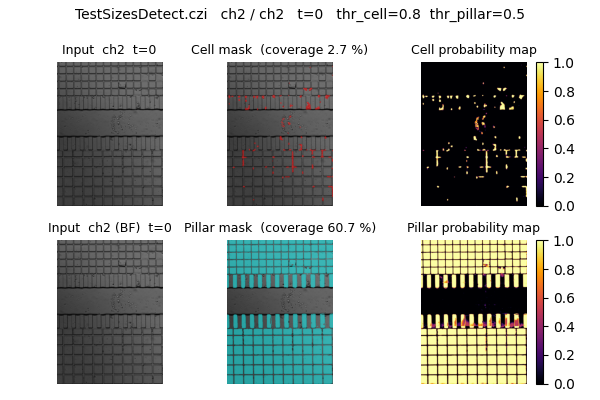

In [8]:
def _overlay_mask(img_norm, mask, color=(1, 0.1, 0.1), alpha=0.6):
    """Return an RGB image with `mask` pixels tinted in `color`."""
    rgb = np.stack([img_norm] * 3, axis=-1).copy()
    for k, c in enumerate(color):
        rgb[mask, k] = rgb[mask, k] * (1 - alpha) + c * alpha
    return np.clip(rgb, 0, 1)


# ── Cell / organism overlay (red tint) ────────────────────────────────────────
cell_overlay   = _overlay_mask(res_cell["img_norm"],   res_cell["pred_binary"],   color=(1, 0.1, 0.1))
# ── Pillar overlay (cyan tint) ────────────────────────────────────────────────
pillar_overlay = _overlay_mask(res_pillar["img_norm"], res_pillar["pred_binary"], color=(0.1, 0.9, 0.9))

fig, axes = plt.subplots(2, 3, figsize=(6, 4))

# Row 0 — cell / organism model
axes[0, 0].imshow(res_cell["img_norm"], cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title(f"Input  ch{CHANNEL}  t={TIMEPOINT}", fontsize=9)

axes[0, 1].imshow(cell_overlay)
axes[0, 1].set_title(
    f"Cell mask  (coverage {res_cell['coverage']*100:.1f} %)", fontsize=9
)

im0 = axes[0, 2].imshow(res_cell["prob_map"], cmap="inferno", vmin=0, vmax=1)
plt.colorbar(im0, ax=axes[0, 2], fraction=0.046)
axes[0, 2].set_title("Cell probability map", fontsize=9)

# Row 1 — pillar model
axes[1, 0].imshow(res_pillar["img_norm"], cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title(f"Input  ch{CHANNEL_BF} (BF)  t={TIMEPOINT}", fontsize=9)

axes[1, 1].imshow(pillar_overlay)
axes[1, 1].set_title(
    f"Pillar mask  (coverage {res_pillar['coverage']*100:.1f} %)", fontsize=9
)

im1 = axes[1, 2].imshow(res_pillar["prob_map"], cmap="inferno", vmin=0, vmax=1)
plt.colorbar(im1, ax=axes[1, 2], fraction=0.046)
axes[1, 2].set_title("Pillar probability map", fontsize=9)

for ax in axes.flat:
    ax.axis("off")

plt.suptitle(
    f"{czi_path.name}   ch{CHANNEL} / ch{CHANNEL_BF}   t={TIMEPOINT}   "
    f"thr_cell={THRESHOLD_CELL}  thr_pillar={THRESHOLD_PILLAR}",
    fontsize=10,
)
plt.tight_layout()
plt.show()

## Combined overlay — cells on brightfield + pillars

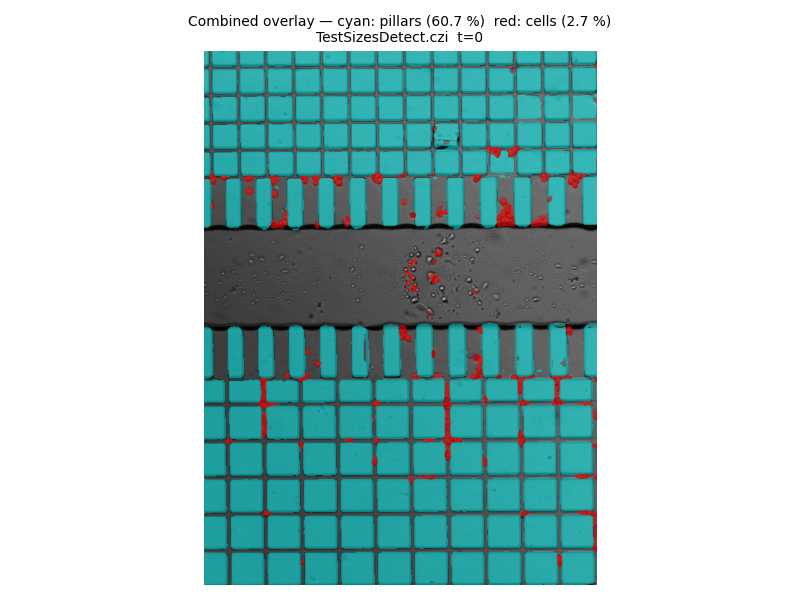

In [9]:
# Show both predictions overlaid on the brightfield image.
# Pillars = cyan, cells/organisms = red.
# If images have different shapes the cell channel is resized to match the BF image.

from skimage.transform import resize as sk_resize

bf_norm   = res_pillar["img_norm"]   # brightfield, normalised
cell_mask = res_cell["pred_binary"]
pillar_mask = res_pillar["pred_binary"]

# Resize cell mask to BF shape if needed
if cell_mask.shape != bf_norm.shape:
    cell_mask = sk_resize(
        cell_mask.astype(np.float32), bf_norm.shape,
        order=0, preserve_range=True, anti_aliasing=False,
    ).astype(bool)

combo = np.stack([bf_norm] * 3, axis=-1).copy()

# Cyan for pillars
alpha_p = 0.5
combo[pillar_mask, 0] = combo[pillar_mask, 0] * (1 - alpha_p)
combo[pillar_mask, 1] = combo[pillar_mask, 1] * (1 - alpha_p) + alpha_p
combo[pillar_mask, 2] = combo[pillar_mask, 2] * (1 - alpha_p) + alpha_p

# Red for cells (drawn on top)
alpha_c = 0.6
combo[cell_mask, 0] = combo[cell_mask, 0] * (1 - alpha_c) + alpha_c
combo[cell_mask, 1] = combo[cell_mask, 1] * (1 - alpha_c)
combo[cell_mask, 2] = combo[cell_mask, 2] * (1 - alpha_c)

combo = np.clip(combo, 0, 1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(combo)
ax.set_title(
    f"Combined overlay — cyan: pillars ({res_pillar['coverage']*100:.1f} %)  "
    f"red: cells ({res_cell['coverage']*100:.1f} %)\n"
    f"{czi_path.name}  t={TIMEPOINT}",
    fontsize=10,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Detected pillars — bounding-box vertices

Detected 166 pillars  (min area 100.0 µm²,  max background 35 %)


/Users/bisot/Documents/PostDoc2/chipanalysis/chipanalysis/functions/pillar_detection.py:44: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(pred_binary.copy(), min_size=min_px)
/Users/bisot/Documents/PostDoc2/chipanalysis/chipanalysis/functions/pillar_detection.py:45: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous paramet

,id,centroid_col,centroid_row,width_px,height_px,width_um,height_um,area_um2,angle_deg,black_frac
0,1,188.0,830.5,51.000000,52.000000,62.383930,63.607144,3940.382907,-90.0,0.007620
1,2,128.5,830.5,51.000000,53.000000,62.383930,64.830358,3988.263011,-90.0,0.014601
2,3,70.0,830.5,50.999992,51.999992,62.383920,63.607135,3947.864173,-90.0,0.005806
3,4,422.5,830.0,52.000000,53.000000,63.607144,64.830358,4050.357520,-90.0,0.018868
4,5,364.0,830.0,51.999992,51.999992,63.607135,63.607135,4027.165595,-90.0,0.005696
...,...,...,...,...,...,...,...,...,...,...
161,162,165.5,12.5,25.000000,41.000000,30.580358,50.151787,1472.313188,-90.0,0.040293
162,163,121.0,13.0,26.000000,40.000000,31.803572,48.928572,1505.230759,-90.0,0.033424
163,164,76.5,13.0,26.000000,41.000000,31.803572,50.151787,1504.482633,-90.0,0.056437
164,165,32.0,13.0,26.000000,40.000000,31.803572,48.928572,1528.422684,-90.0,0.018970


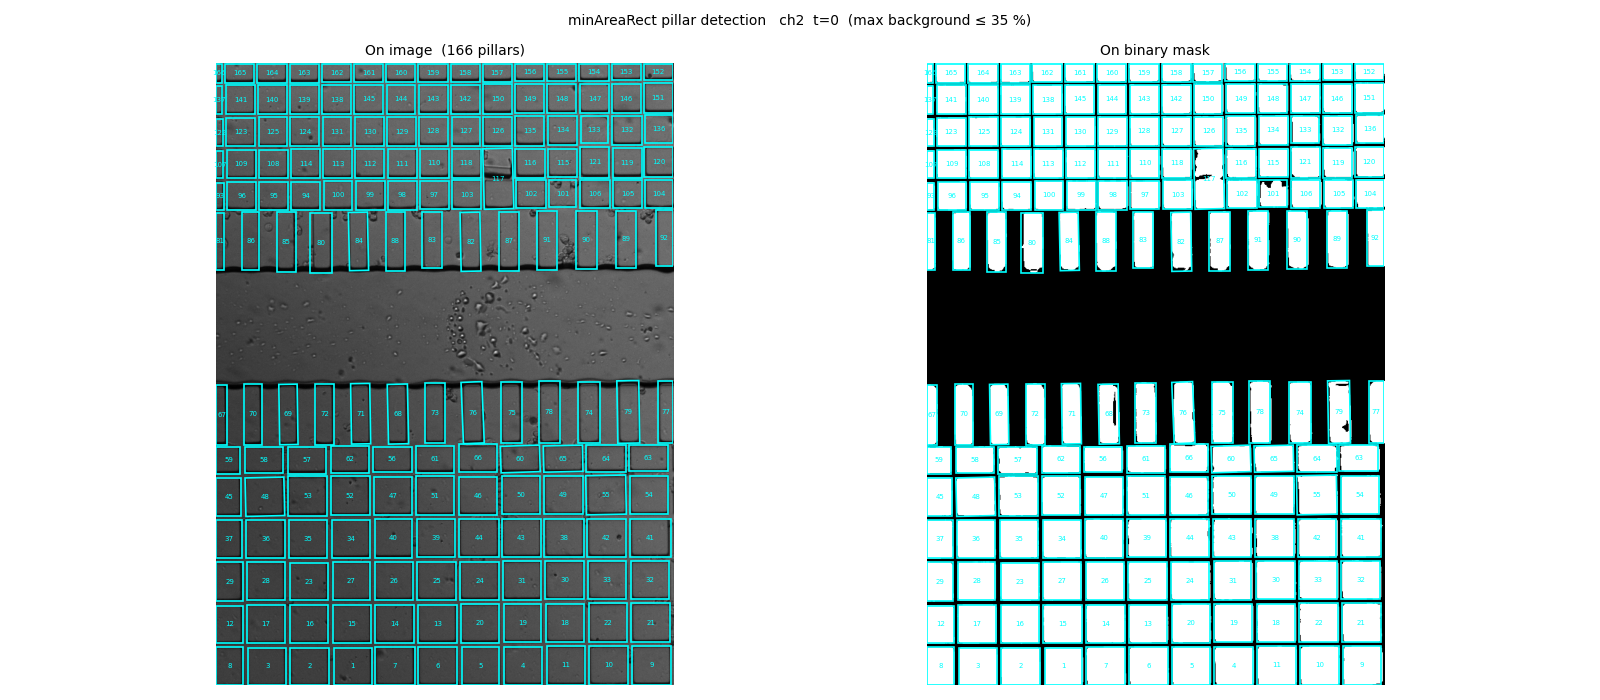

In [10]:
from importlib import reload
import chipanalysis.functions.pillar_detection as pd_mod
reload(pd_mod)  # picks up edits to the module without restarting the kernel
from chipanalysis.functions.pillar_detection import (
    clean_pillar_mask, detect_pillars, pillars_to_dataframe,
    estimate_grid_rotation, rotate_and_redetect, draw_pillar_boxes,
)
import pandas as pd

# ── Parameters ────────────────────────────────────────────────────────────────
MIN_PILLAR_UM2 = 100.0   # discard blobs smaller than this (µm²)
MAX_BLACK_FRAC = 0.35    # max background fraction allowed inside a box

# ── Detect pillars ────────────────────────────────────────────────────────────
pillar_clean = clean_pillar_mask(res_pillar["pred_binary"], px_um, MIN_PILLAR_UM2)
pillar_list  = detect_pillars(pillar_clean, px_um, MAX_BLACK_FRAC, MIN_PILLAR_UM2)
df_pillars   = pillars_to_dataframe(pillar_list)

print(f"Detected {len(pillar_list)} pillars  "
      f"(min area {MIN_PILLAR_UM2} µm²,  max background {MAX_BLACK_FRAC*100:.0f} %)")
display(df_pillars)

# ── Visualise: boxes on image AND on binary mask side-by-side ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(res_pillar["img_norm"], cmap="gray", vmin=0, vmax=1)
axes[1].imshow(pillar_clean, cmap="gray", vmin=0, vmax=1)
for ax in axes:
    draw_pillar_boxes(ax, pillar_list, color="cyan", fontsize=5)
    ax.axis("off")
axes[0].set_title(f"On image  ({len(pillar_list)} pillars)", fontsize=10)
axes[1].set_title("On binary mask", fontsize=10)
plt.suptitle(
    f"minAreaRect pillar detection   ch{CHANNEL_BF}  t={TIMEPOINT}  "
    f"(max background ≤ {MAX_BLACK_FRAC*100:.0f} %)",
    fontsize=10,
)
plt.tight_layout()
plt.show()


Estimated grid tilt  : -0.11°
Correction to apply  : 0.11°
Pillars after rotation: 166


/Users/bisot/Documents/PostDoc2/chipanalysis/chipanalysis/functions/pillar_detection.py:44: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  clean = remove_small_objects(pred_binary.copy(), min_size=min_px)
/Users/bisot/Documents/PostDoc2/chipanalysis/chipanalysis/functions/pillar_detection.py:45: FutureWarning: Parameter `area_threshold` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_holes`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous paramet

,id,centroid_col,centroid_row,width_px,height_px,width_um,height_um,area_um2,angle_deg,black_frac
0,1,189.000000,830.500000,51.000000,52.000000,62.383930,63.607144,3940.382907,-90.0,0.007620
1,2,129.500000,830.500000,51.000000,53.000000,62.383930,64.830358,3988.263011,-90.0,0.014601
2,3,71.000000,830.500000,50.999992,51.999992,62.383920,63.607135,3936.642274,-90.0,0.008708
3,4,19.500000,830.500000,51.000000,37.000000,62.383930,45.258929,2753.854088,-90.0,0.024798
4,5,423.500000,829.500000,51.000000,53.000000,62.383930,64.830358,3977.789238,-90.0,0.017450
5,6,365.000000,829.500000,50.999992,51.999992,62.383920,63.607135,3953.849186,-90.0,0.004717
6,7,306.000000,830.000000,52.000000,54.000000,63.607144,66.053573,4026.417468,-90.0,0.041852
7,8,247.000000,830.000000,52.000000,54.000000,63.607144,66.053573,4021.928708,-90.0,0.042882
8,9,541.499939,829.000000,51.999992,52.999992,63.607135,64.830349,4060.083166,-90.0,0.032145
9,10,482.500000,829.000000,52.000000,53.000000,63.607144,64.830358,4027.165595,-90.0,0.024109


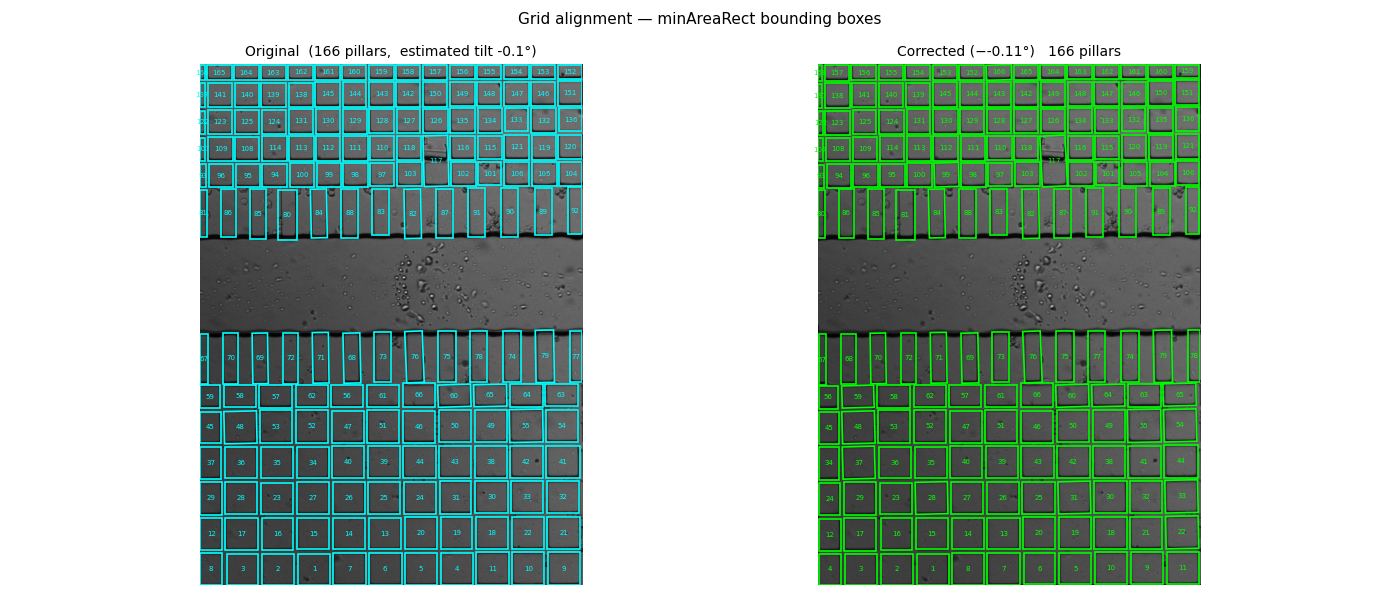

In [11]:
# ── Estimate grid tilt and produce an axis-aligned version ───────────────────
rotation_deg = -estimate_grid_rotation(pillar_list)
print(f"Estimated grid tilt  : {rotation_deg:.2f}°")
print(f"Correction to apply  : {-rotation_deg:.2f}°")

img_rot, pillar_clean_rot, pillar_list_rot = rotate_and_redetect(
    res_pillar["img_norm"], res_pillar["pred_binary"],
    rotation_deg, px_um, MIN_PILLAR_UM2, MAX_BLACK_FRAC,
)
df_pillars_rot = pillars_to_dataframe(pillar_list_rot)

print(f"Pillars after rotation: {len(pillar_list_rot)}")
display(df_pillars_rot.head(20))

# ── Side-by-side figure ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(res_pillar["img_norm"], cmap="gray", vmin=0, vmax=1)
draw_pillar_boxes(axes[0], pillar_list, color="cyan")
axes[0].set_title(
    f"Original  ({len(pillar_list)} pillars,  estimated tilt {rotation_deg:.1f}°)",
    fontsize=10)
axes[0].axis("off")

axes[1].imshow(img_rot, cmap="gray", vmin=0, vmax=1)
draw_pillar_boxes(axes[1], pillar_list_rot, color="lime")
axes[1].set_title(
    f"Corrected (−{rotation_deg:.2f}°)   {len(pillar_list_rot)} pillars",
    fontsize=10)
axes[1].axis("off")

plt.suptitle("Grid alignment — minAreaRect bounding boxes", fontsize=11)
plt.tight_layout()
plt.show()


## Horizontal band detection

The pillar grid is split into two vertical groups by a wide horizontal band.
We cluster pillar centroids into **top** and **bottom** groups with k-means
(k=2 on the row coordinate), then define the band as the gap between the
**lowest edge** of the top group and the **highest edge** of the bottom group.

Top group    : 87 pillars
Bottom group : 79 pillars

Band top edge    : row 288.0  (352.3 µm)
Band bottom edge : row 436.8  (534.2 µm)
Band width       : 148.8 px  = 182.0 µm


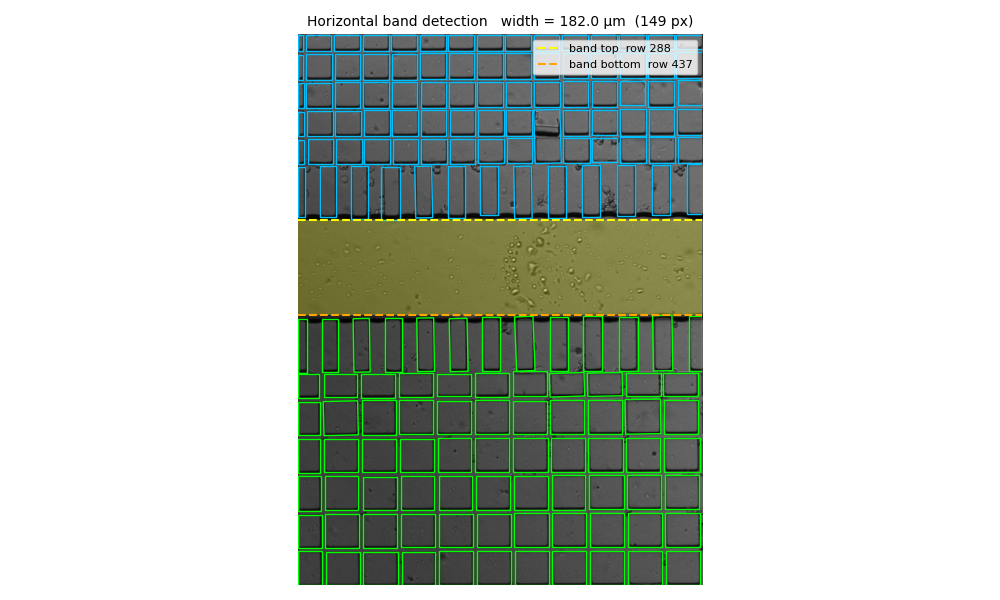

In [12]:
from sklearn.cluster import KMeans

# ── Cluster pillar centroids into top / bottom group by row coordinate ────────
centroid_rows = np.array([p["centroid_row"] for p in pillar_list]).reshape(-1, 1)

km = KMeans(n_clusters=2, n_init="auto", random_state=0).fit(centroid_rows)
labels = km.labels_

# Ensure group 0 = top (smaller row index), group 1 = bottom
if km.cluster_centers_[0] > km.cluster_centers_[1]:
    labels = 1 - labels

group_top    = [p for p, lbl in zip(pillar_list, labels) if lbl == 0]
group_bottom = [p for p, lbl in zip(pillar_list, labels) if lbl == 1]

print(f"Top group    : {len(group_top)} pillars")
print(f"Bottom group : {len(group_bottom)} pillars")

# ── Band edges: max lower-vertex of top group, min upper-vertex of bottom group
# corners_rc is (4,2) as (row, col); take the max/min row across all 4 corners.
band_top    = max(p["corners_rc"][:, 0].max() for p in group_top)
band_bottom = min(p["corners_rc"][:, 0].min() for p in group_bottom)

print(f"\nBand top edge    : row {band_top:.1f}  ({band_top * px_um:.1f} µm)")
print(f"Band bottom edge : row {band_bottom:.1f}  ({band_bottom * px_um:.1f} µm)")
print(f"Band width       : {band_bottom - band_top:.1f} px  "
      f"= {(band_bottom - band_top) * px_um:.1f} µm")

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(res_pillar["img_norm"], cmap="gray", vmin=0, vmax=1)

# Pillar boxes coloured by group
for p, lbl in zip(pillar_list, labels):
    color = "deepskyblue" if lbl == 0 else "lime"
    ax.add_patch(plt.Polygon(p["corners_xy"], closed=True,
                             lw=1, edgecolor=color, facecolor="none"))

# Horizontal band as a filled rectangle spanning the full image width
W = res_pillar["img_norm"].shape[1]
band_patch = plt.Rectangle(
    (0, band_top), W, band_bottom - band_top,
    linewidth=0, facecolor="yellow", alpha=0.25,
)
ax.add_patch(band_patch)

# Band edge lines
ax.axhline(band_top,    color="yellow", lw=1.5, linestyle="--", label=f"band top  row {band_top:.0f}")
ax.axhline(band_bottom, color="orange", lw=1.5, linestyle="--", label=f"band bottom  row {band_bottom:.0f}")

ax.legend(fontsize=8, loc="upper right")
ax.set_title(
    f"Horizontal band detection   "
    f"width = {(band_bottom - band_top) * px_um:.1f} µm  "
    f"({band_bottom - band_top:.0f} px)",
    fontsize=10,
)
ax.axis("off")
plt.tight_layout()
plt.show()


## Re-run cell detection at a different timepoint

The pillar grid, band edges and `band_centre_row` are **fixed** from the detection
above.  Only the cell-channel image is reloaded and re-inferred here.
Set `TIMEPOINT_CELLS` to any T index; leave it equal to `TIMEPOINT` to reproduce
the original result.

In [13]:
TIMEPOINT_CELLS = 56   # ← change this independently of the pillar timepoint

# ── Load cell channel at the requested timepoint ─────────────────────────────
img_cell_t, _ = get_frame(
    czi, TIMEPOINT_CELLS, CHANNEL,
    gamma=GAMMA, stretch_min=STRETCH_MIN, stretch_max=STRETCH_MAX,
)

# ── Run cell ML model ─────────────────────────────────────────────────────────
print(f"Running cell model  ch{CHANNEL}  t={TIMEPOINT_CELLS} …")
res_cell_t = predict_unet(
    img_cell_t,
    model_path   = CELL_MODEL_PATH,
    threshold    = THRESHOLD_CELL,
    patch_size   = PATCH_SIZE_PX,
    patch_stride = PATCH_STRIDE_PX,
)
print(f"  Done.  Coverage = {res_cell_t['coverage']*100:.2f} %")


Running cell model  ch2  t=56 …
  Done.  Coverage = 0.65 %


Detected 25 cell objects  (t=56)
Band centre fixed at row 362.4  (443.3 µm from top,  detected at t=0)


/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_77320/1140792192.py:18: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  cell_bin     = sk_remove_small(cell_bin, min_size=10)


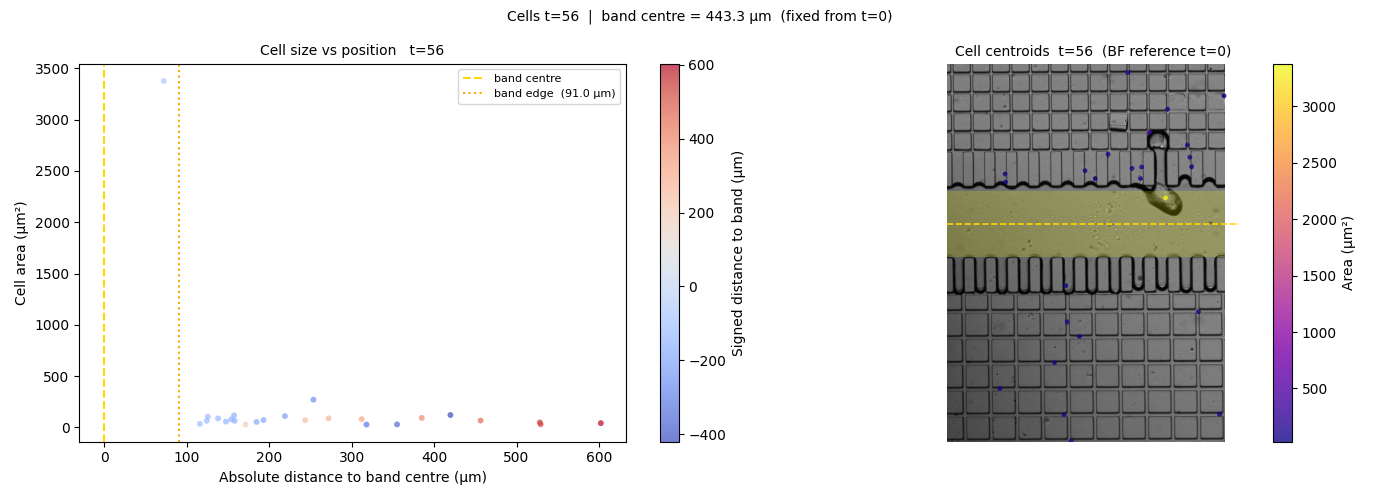

In [14]:

from skimage.measure import label as sk_label, regionprops as sk_regionprops
from skimage.morphology import remove_small_objects as sk_remove_small
from skimage.transform import resize as sk_resize

# ── Band centre (fixed from pillar detection above) ───────────────────────────
band_centre_row = (band_top + band_bottom) / 2.0
band_half_width_um = (band_bottom - band_top) / 2.0 * px_um

# ── Label individual cell objects from the selected timepoint ─────────────────
cell_bin = res_cell_t["pred_binary"].copy()
H_bf, W_bf = res_pillar["img_norm"].shape
if cell_bin.shape != (H_bf, W_bf):
    cell_bin = sk_resize(
        cell_bin.astype(np.float32), (H_bf, W_bf),
        order=0, preserve_range=True, anti_aliasing=False,
    ).astype(bool)

cell_bin     = sk_remove_small(cell_bin, min_size=10)
cell_labeled = sk_label(cell_bin)
cell_regions = sk_regionprops(cell_labeled)

# ── Build DataFrame ───────────────────────────────────────────────────────────
records = []
for reg in cell_regions:
    cy, cx   = reg.centroid
    dist_px  = cy - band_centre_row   # signed: negative = top half
    records.append({
        "id":               reg.label,
        "centroid_row":     cy,
        "centroid_col":     cx,
        "dist_to_band_px":  dist_px,
        "dist_to_band_um":  dist_px * px_um,
        "area_px":          reg.area,
        "area_um2":         reg.area * px_um ** 2,
    })

df_cells = pd.DataFrame(records)
print(f"Detected {len(df_cells)} cell objects  (t={TIMEPOINT_CELLS})")
print(f"Band centre fixed at row {band_centre_row:.1f}  "
      f"({band_centre_row * px_um:.1f} µm from top,  "
      f"detected at t={TIMEPOINT})")

# ── Plot: distance to band centre vs cell area ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    np.abs(df_cells["dist_to_band_um"]), df_cells["area_um2"],
    c=df_cells["dist_to_band_um"], cmap="coolwarm",
    s=18, alpha=0.7, linewidths=0,
)
plt.colorbar(sc, ax=axes[0], label="Signed distance to band (µm)")
axes[0].axvline(0, color="gold", lw=1.5, linestyle="--", label="band centre")
axes[0].axvline(band_half_width_um, color="orange", lw=1.5, linestyle=":",
                label=f"band edge  ({band_half_width_um:.1f} µm)")
axes[0].set_xlabel("Absolute distance to band centre (µm)")
axes[0].set_ylabel("Cell area (µm²)")
axes[0].set_title(f"Cell size vs position   t={TIMEPOINT_CELLS}", fontsize=10)
axes[0].legend(fontsize=8)

# Overlay centroids on the BF image (pillar timepoint) for spatial context
axes[1].imshow(img_cell_t, cmap="gray")
sc2 = axes[1].scatter(
    df_cells["centroid_col"], df_cells["centroid_row"],
    c=df_cells["area_um2"], cmap="plasma",
    s=12, alpha=0.8, linewidths=0,
)
plt.colorbar(sc2, ax=axes[1], label="Area (µm²)")
W = res_pillar["img_norm"].shape[1]
axes[1].add_patch(plt.Rectangle(
    (0, band_top), W, band_bottom - band_top,
    linewidth=0, facecolor="yellow", alpha=0.2,
))
axes[1].axhline(band_centre_row, color="gold", lw=1.2, linestyle="--")
axes[1].set_title(
    f"Cell centroids  t={TIMEPOINT_CELLS}  (BF reference t={TIMEPOINT})",
    fontsize=10)
axes[1].axis("off")

plt.suptitle(
    f"Cells t={TIMEPOINT_CELLS}  |  band centre = {band_centre_row * px_um:.1f} µm  "
    f"(fixed from t={TIMEPOINT})",
    fontsize=10,
)
plt.tight_layout()
plt.show()
